In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
from lightgbm import LGBMRegressor, early_stopping, log_evaluation

In [30]:
s1_df = pd.read_csv('rome_s1_features.csv', low_memory=False)
lst_df = pd.read_csv('rome_final_landsat.csv', low_memory=False)
s2_df = pd.read_csv('rome_s2_features_v4.csv', low_memory=False)
srtm_df = pd.read_csv('rome_srtm_elevation_30m.csv', low_memory=False)

In [31]:
s1_df.head()

,VV,VH,VV_VH_diff,VH_VV_ratio,RFDI,SAR_urban,VV_std,VH_std,texture_contrast,x_utm,y_utm,lon,lat
0,-10.388566,-16.534420,6.145855,0.242893,0.609149,-4.242711,0.527717,0.708021,0.590561,280515.0,4653165.0,12.349883,41.999919
1,-10.671421,-16.463101,5.791680,0.263531,0.582866,-4.879741,0.641854,0.906207,0.673612,280545.0,4653165.0,12.350245,41.999928
2,-10.706261,-16.585046,5.878785,0.258298,0.589448,-4.827475,0.468242,0.716338,0.682525,280575.0,4653165.0,12.350606,41.999936
3,-10.472099,-16.476226,6.004127,0.250950,0.598785,-4.467972,0.590233,0.698900,0.675634,280605.0,4653165.0,12.350968,41.999944
4,-10.537540,-16.623564,6.086025,0.246262,0.604799,-4.451515,0.597549,0.548910,0.677846,280635.0,4653165.0,12.351330,41.999953


In [32]:
lst_df.head()

,LST,x_utm,y_utm
0,48.203660,280515.0,4653165.0
1,47.978070,280545.0,4653165.0
2,47.728554,280575.0,4653165.0
3,47.314972,280605.0,4653165.0
4,46.870632,280635.0,4653165.0


In [33]:
s2_df.head()

,NDVI,NDBI,NDWI,Albedo,PIS,PGS,NLI,x_utm,y_utm
0,0.304037,0.072054,-0.415314,0.106103,0.0,1.0,4.18,280515.0,4653165.0
1,0.334911,0.068923,-0.436943,0.094604,0.0,1.0,4.18,280545.0,4653165.0
2,0.370341,-0.010526,-0.481143,0.098444,0.0,1.0,4.18,280575.0,4653165.0
3,0.366675,-0.024875,-0.462777,0.101344,0.0,1.0,4.18,280605.0,4653165.0
4,0.393722,-0.046630,-0.476846,0.092789,0.0,1.0,4.18,280635.0,4653165.0


In [34]:
s2_df['PGS'].describe()

count    677735.000000
mean          0.635307
std           0.427536
min           0.000000
25%           0.110620
50%           0.951345
75%           1.000000
max           1.000000
Name: PGS, dtype: float64

In [35]:
srtm_df.head()

,elevation,x_utm,y_utm
0,133.0,280515.0,4653165.0
1,132.0,280545.0,4653165.0
2,131.0,280575.0,4653165.0
3,129.0,280605.0,4653165.0
4,126.0,280635.0,4653165.0


In [36]:
s1_df.shape, lst_df.shape, s2_df.shape, srtm_df.shape

((677735, 13), (677735, 3), (677735, 9), (677735, 3))

In [37]:
df = s1_df.merge(s2_df, on=['x_utm', 'y_utm'], how='inner')
df = df.merge(lst_df, on=['x_utm', 'y_utm'], how='inner')
df = df.merge(srtm_df, on=['x_utm', 'y_utm'], how='inner')
print('Merged DataFrame shape:', df.shape)

Merged DataFrame shape: (677735, 22)


In [38]:
df.head()

,VV,VH,VV_VH_diff,VH_VV_ratio,RFDI,SAR_urban,VV_std,VH_std,texture_contrast,x_utm,...,lat,NDVI,NDBI,NDWI,Albedo,PIS,PGS,NLI,LST,elevation
0,-10.388566,-16.534420,6.145855,0.242893,0.609149,-4.242711,0.527717,0.708021,0.590561,280515.0,...,41.999919,0.304037,0.072054,-0.415314,0.106103,0.0,1.0,4.18,48.203660,133.0
1,-10.671421,-16.463101,5.791680,0.263531,0.582866,-4.879741,0.641854,0.906207,0.673612,280545.0,...,41.999928,0.334911,0.068923,-0.436943,0.094604,0.0,1.0,4.18,47.978070,132.0
2,-10.706261,-16.585046,5.878785,0.258298,0.589448,-4.827475,0.468242,0.716338,0.682525,280575.0,...,41.999936,0.370341,-0.010526,-0.481143,0.098444,0.0,1.0,4.18,47.728554,131.0
3,-10.472099,-16.476226,6.004127,0.250950,0.598785,-4.467972,0.590233,0.698900,0.675634,280605.0,...,41.999944,0.366675,-0.024875,-0.462777,0.101344,0.0,1.0,4.18,47.314972,129.0
4,-10.537540,-16.623564,6.086025,0.246262,0.604799,-4.451515,0.597549,0.548910,0.677846,280635.0,...,41.999953,0.393722,-0.046630,-0.476846,0.092789,0.0,1.0,4.18,46.870632,126.0


In [39]:
df['PIS'].describe()

count    677735.000000
mean          0.355760
std           0.425458
min           0.000000
25%           0.000000
50%           0.026093
75%           0.870543
max           1.000000
Name: PIS, dtype: float64

In [40]:
df['PGS'].describe()

count    677735.000000
mean          0.635307
std           0.427536
min           0.000000
25%           0.110620
50%           0.951345
75%           1.000000
max           1.000000
Name: PGS, dtype: float64

In [41]:
# # save dataframe for later use
df.to_csv('rome_dataset_features_target_v2.csv', index=False)
print('Saved: rome_dataset_features_target_v2.csv')

Saved: rome_dataset_features_target_v2.csv


# Train-Validation-Test Split

In [42]:
# df = pd.read_csv('rome_dataset_features_target.csv', low_memory=False)
# df.head()

In [43]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
df_train, df_val = train_test_split(df_train, test_size=0.25, random_state=42)  # 0.25 x 0.8 = 0.2

In [44]:
df_train.shape, df_val.shape, df_test.shape

((406641, 22), (135547, 22), (135547, 22))

<Axes: title={'center': 'LST Distribution in Test Set'}, ylabel='Frequency'>

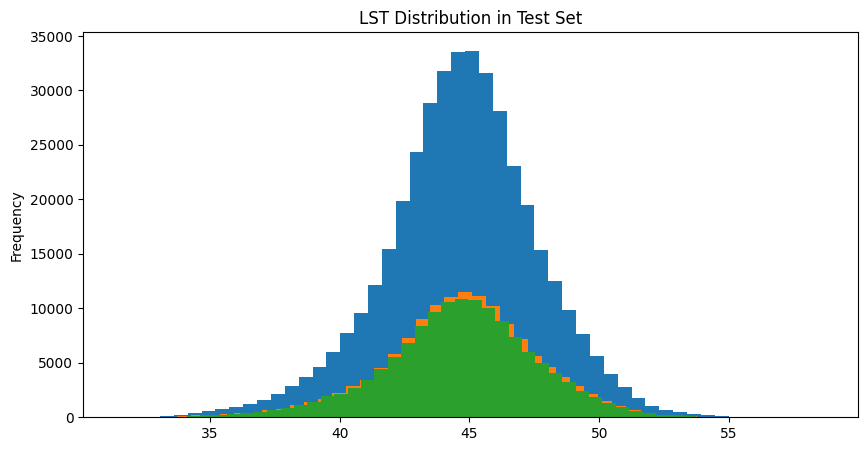

In [45]:
df_train['LST'].plot.hist(bins=50, figsize=(10, 5), title='LST Distribution in Training Set')
df_val['LST'].plot.hist(bins=50, figsize=(10, 5), title='LST Distribution in Validation Set')
df_test['LST'].plot.hist(bins=50, figsize=(10, 5), title='LST Distribution in Test Set')

In [ ]:
# df_train.to_csv('train_random_split_v2.csv', index=False)
# df_val.to_csv('val_random_split_v2.csv', index=False)
# df_test.to_csv('test_random_split_v2.csv', index=False)

# LightGBM model

In [18]:
# df_train = pd.read_csv('train_random_split.csv', low_memory=False)
# df_val = pd.read_csv('val_random_split.csv', low_memory=False)
# df_test = pd.read_csv('test_random_split.csv', low_memory=False)

In [19]:
X_train = df_train.drop(columns=['LST', 'x_utm', 'y_utm', 'lon', 'lat'])#, 'B2', 'B3', 'B4', 'B8'])
X_val = df_val.drop(columns=['LST', 'x_utm', 'y_utm', 'lon', 'lat'])#, 'B2', 'B3', 'B4', 'B8'])
X_test = df_test.drop(columns=['LST', 'x_utm', 'y_utm', 'lon', 'lat'])#, 'B2', 'B3', 'B4', 'B8'])

y_train = df_train['LST']
y_val = df_val['LST']
y_test = df_test['LST']

In [20]:
# print modelling features and target
print('Features:', X_train.columns.tolist())
print('Target:', 'LST')

Features: ['VV', 'VH', 'VV_VH_diff', 'VH_VV_ratio', 'RFDI', 'SAR_urban', 'VV_std', 'VH_std', 'texture_contrast', 'NDVI', 'NDBI', 'NDWI', 'Albedo', 'PIS', 'PGS', 'NLI', 'elevation']
Target: LST


In [21]:
# correlation between input features and target
correlation_matrix = df.corr()
correlation_with_target = correlation_matrix['LST'].sort_values(ascending=False)   
print('Correlation with LST:')
print(correlation_with_target)

Correlation with LST:
LST                 1.000000
NDBI                0.595289
NDWI                0.403011
VH_std              0.376520
Albedo              0.356202
VV_std              0.267874
RFDI                0.210546
VV_VH_diff          0.200583
PIS                 0.170928
texture_contrast    0.134302
lon                 0.103914
x_utm               0.101091
NLI                 0.062610
SAR_urban           0.023972
VV                 -0.084493
lat                -0.094992
y_utm              -0.098015
elevation          -0.105395
PGS                -0.136994
VH_VV_ratio        -0.214655
VH                 -0.225529
NDVI               -0.509111
Name: LST, dtype: float64


In [22]:
# baseline_model = LGBMRegressor(random_state=42, n_estimators=1000, learning_rate=0.1)

# baseline_model.fit(X_train, y_train, eval_set=[(X_train, y_train),(X_val, y_val)], callbacks=[early_stopping(10), log_evaluation(10)])


# baseline_model = LGBMRegressor(
#     n_estimators=1000,
#     learning_rate=0.05,
#     max_depth=6,
#     subsample=0.8,            # same name in LightGBM
#     colsample_bytree=0.8,     # same name in LightGBM
#     random_state=42
# )

baseline_model = LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.05,
    num_leaves=63,          # primary complexity control in LightGBM
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42
)

baseline_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_metric='mae',
    callbacks=[early_stopping(50), log_evaluation(100)]
)

# l1 = mean_absolute_error(y_val, baseline_model.predict(X_val))
# l2 = mean_squared_error(y_val, baseline_model.predict(X_val))


print(f"\nAddestramento terminato all'albero n° {baseline_model.best_iteration_}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.019679 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4335
[LightGBM] [Info] Number of data points in the train set: 406641, number of used features: 17
[LightGBM] [Info] Start training from score 44.670692
Training until validation scores don't improve for 50 rounds
[100]	training's l1: 1.42277	training's l2: 3.29676	valid_1's l1: 1.43282	valid_1's l2: 3.34536
[200]	training's l1: 1.36818	training's l2: 3.05113	valid_1's l1: 1.38504	valid_1's l2: 3.12843
[300]	training's l1: 1.3378	training's l2: 2.92188	valid_1's l1: 1.36102	valid_1's l2: 3.02515
[400]	training's l1: 1.31083	training's l2: 2.8105	valid_1's l1: 1.34016	valid_1's l2: 2.93787
[500]	training's l1: 1.28975	training's l2: 2.72564	valid_1's l1: 1.32462	valid_1's l2: 2.87451
[600]	training's l1: 1.27028	training's l2: 2.64702	valid_1's l1: 1.31083	valid_1's l2: 2.81869
[700]	training's l1: 

In [23]:
# make predictions
pred_train = baseline_model.predict(X_train)
pred_val = baseline_model.predict(X_val)
pred_test = baseline_model.predict(X_test)


# compute R2, MAE, MAPE, RMSE
def compute_metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred)
    return r2, mae, mape, np.sqrt(rmse)

train_metrics = compute_metrics(y_train, pred_train)
val_metrics = compute_metrics(y_val, pred_val)
test_metrics = compute_metrics(y_test, pred_test)

print(f"Train Metrics: R2={train_metrics[0]:.2f}, MAE={train_metrics[1]:.4f}, MAPE={train_metrics[2]:.1%}, RMSE={train_metrics[3]:.4f}")
print(f"Validation Metrics: R2={val_metrics[0]:.2f}, MAE={val_metrics[1]:.4f}, MAPE={val_metrics[2]:.1%}, RMSE={val_metrics[3]:.4f}")
print(f"Test Metrics: R2={test_metrics[0]:.2f}, MAE={test_metrics[1]:.4f}, MAPE={test_metrics[2]:.1%}, RMSE={test_metrics[3]:.4f}")

Train Metrics: R2=0.80, MAE=1.0178, MAPE=2.3%, RMSE=1.3219
Validation Metrics: R2=0.73, MAE=1.1692, MAPE=2.6%, RMSE=1.5141
Test Metrics: R2=0.73, MAE=1.1717, MAPE=2.6%, RMSE=1.5157


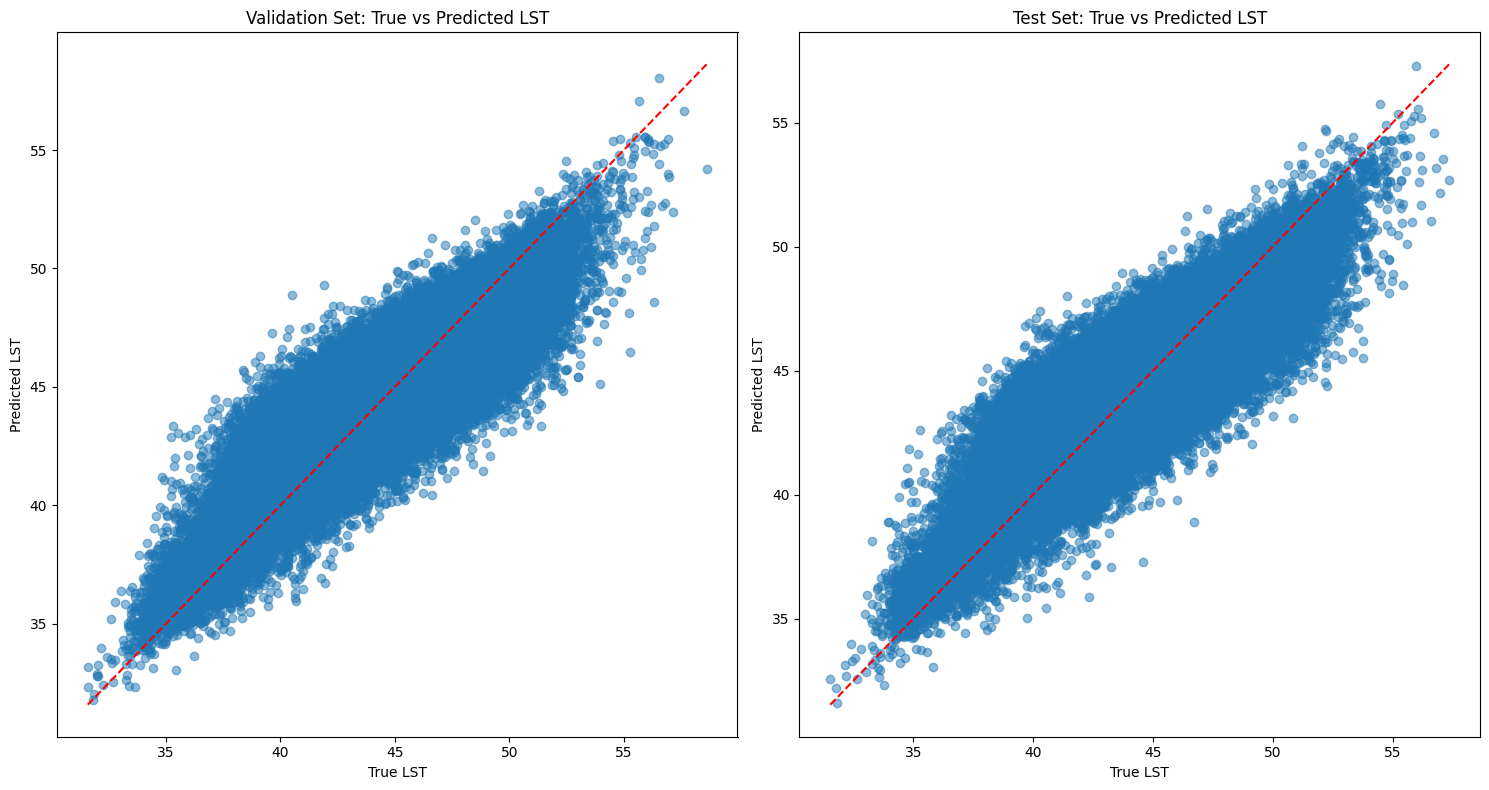

In [24]:
# plot predictions vs true values
plt.figure(figsize=(15, 8))

plt.subplot(1, 2, 1)
plt.scatter(y_val, pred_val, alpha=0.5)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.xlabel('True LST')
plt.ylabel('Predicted LST')
plt.title('Validation Set: True vs Predicted LST')
plt.subplot(1, 2, 2)
plt.scatter(y_test, pred_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('True LST')
plt.ylabel('Predicted LST')
plt.title('Test Set: True vs Predicted LST')
plt.tight_layout()
plt.show()

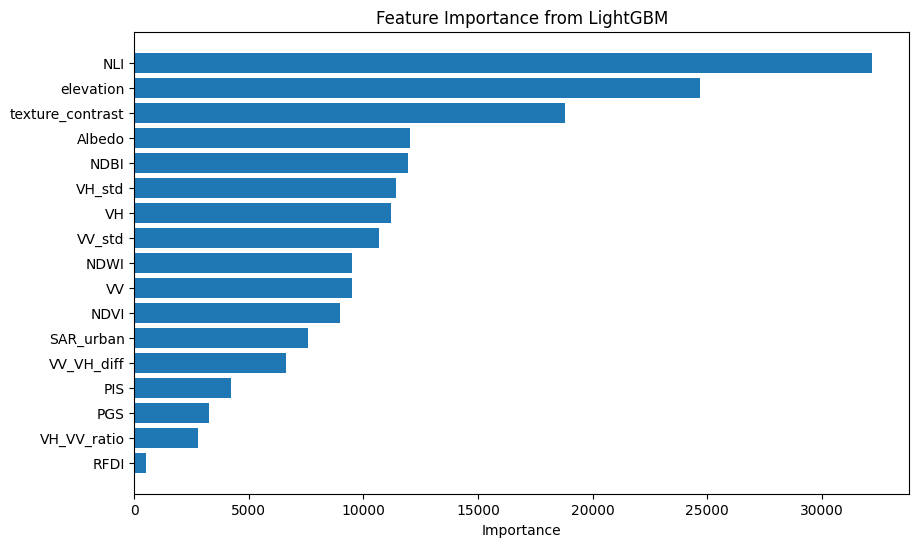

In [25]:
# plote feature importance
importances = baseline_model.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=True)
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance from LightGBM')
plt.show()

In [ ]:
'''
1) add neighborhood features (mean, std, min, max of 3x3 window) for each feature (except coordinates and target)
'''

# Additional neighborhood Features

In [47]:
from scipy.ndimage import uniform_filter
import numpy as np

FEATURE_COLS = ['VV', 'VH', 'VV_VH_diff', 'VH_VV_ratio', 'RFDI', 'SAR_urban',
                'VV_std', 'VH_std', 'texture_contrast', 'NDVI', 'NDBI', 'NDWI',
                'Albedo', 'PIS', 'PGS', 'NLI', 'elevation']

WINDOW = 5   # 5x5 pixels = 150m x 150m neighbourhood (one city block)

def add_focal_features(df, feature_cols, window=5):
    df = df.copy()

    # Step 1 — reconstruct grid dimensions from UTM coordinates
    xs = np.sort(df['x_utm'].unique())          # ascending west→east
    ys = np.sort(df['y_utm'].unique())[::-1]    # descending north→south

    H, W = len(ys), len(xs)
    print(f'Grid size: {H} rows x {W} cols')

    # Step 2 — map each pixel to its row/col index in the 2D grid
    x_to_col = {x: i for i, x in enumerate(xs)}
    y_to_row = {y: i for i, y in enumerate(ys)}

    row_idx = df['y_utm'].map(y_to_row).values
    col_idx = df['x_utm'].map(x_to_col).values

    # Step 3 — for each feature, build 2D grid → focal mean → read back
    new_cols = {}
    for feat in feature_cols:
        # Fill the 2D grid
        grid = np.full((H, W), np.nan)
        grid[row_idx, col_idx] = df[feat].values

        # NaN pixels (masked/missing) replaced with feature mean
        # so they don't corrupt neighbours' focal values
        fill_val = np.nanmean(grid)
        grid_filled = np.where(np.isnan(grid), fill_val, grid)

        # Focal mean with reflect padding at borders
        focal = uniform_filter(grid_filled, size=window, mode='reflect')

        # Read back only the valid pixel positions
        new_cols[f'{feat}_focal'] = focal[row_idx, col_idx]

        print(f'  {feat}_focal computed')

    # Step 4 — attach all focal columns at once (faster than column-by-column)
    focal_df = pd.DataFrame(new_cols, index=df.index)
    df = pd.concat([df, focal_df], axis=1)

    return df

# Run it
df = add_focal_features(df, FEATURE_COLS, window=WINDOW)

print(f'\nOriginal features : {len(FEATURE_COLS)}')
print(f'New focal features: {len(FEATURE_COLS)}')
print(f'Total features    : {len(FEATURE_COLS) * 2}')
print(f'Dataset shape     : {df.shape}')

Grid size: 839 rows x 855 cols
  VV_focal computed
  VH_focal computed
  VV_VH_diff_focal computed
  VH_VV_ratio_focal computed
  RFDI_focal computed
  SAR_urban_focal computed
  VV_std_focal computed
  VH_std_focal computed
  texture_contrast_focal computed
  NDVI_focal computed
  NDBI_focal computed
  NDWI_focal computed
  Albedo_focal computed
  PIS_focal computed
  PGS_focal computed
  NLI_focal computed
  elevation_focal computed

Original features : 17
New focal features: 17
Total features    : 34
Dataset shape     : (677735, 39)


In [60]:
# save df dataframe with focal features for later use
df.to_csv('rome_dataset_features_target_with_focal.csv', index=False)
print('Saved: rome_dataset_features_target_with_focal.csv')

Saved: rome_dataset_features_target_with_focal.csv


In [48]:
df

,VV,VH,VV_VH_diff,VH_VV_ratio,RFDI,SAR_urban,VV_std,VH_std,texture_contrast,x_utm,...,VH_std_focal,texture_contrast_focal,NDVI_focal,NDBI_focal,NDWI_focal,Albedo_focal,PIS_focal,PGS_focal,NLI_focal,elevation_focal
0,-10.388566,-16.534420,6.145855,0.242893,0.609149,-4.242711,0.527717,0.708021,0.590561,280515.0,...,0.977068,1.587538,0.352828,0.015332,-0.436662,0.106939,0.142304,0.854123,15.319883,102.512041
1,-10.671421,-16.463101,5.791680,0.263531,0.582866,-4.879741,0.641854,0.906207,0.673612,280545.0,...,0.862766,1.149355,0.357187,0.007971,-0.447947,0.104163,0.071152,0.927061,9.749941,115.936020
2,-10.706261,-16.585046,5.878785,0.258298,0.589448,-4.827475,0.468242,0.716338,0.682525,280575.0,...,0.740293,0.714109,0.372381,-0.000460,-0.465151,0.100093,0.000000,1.000000,4.180000,128.880000
3,-10.472099,-16.476226,6.004127,0.250950,0.598785,-4.467972,0.590233,0.698900,0.675634,280605.0,...,0.798195,0.727414,0.371924,-0.000847,-0.463715,0.100060,0.000000,1.000000,4.180000,127.120000
4,-10.537540,-16.623564,6.086025,0.246262,0.604799,-4.451515,0.597549,0.548910,0.677846,280635.0,...,0.813316,0.725861,0.375469,-0.011931,-0.465996,0.101998,0.000000,1.000000,4.180000,125.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
677730,-8.839613,-14.613787,5.774173,0.264596,0.581533,-3.065440,0.620006,0.601262,1.719023,304575.0,...,0.602986,1.617365,0.586193,-0.163182,-0.596486,0.114519,0.045222,0.954778,10.156000,272.000000
677731,-8.970717,-14.564984,5.594267,0.275787,0.567660,-3.376450,0.531116,0.640229,0.853528,304605.0,...,0.661344,1.201262,0.588148,-0.169528,-0.593094,0.112905,0.050017,0.949983,10.260000,274.920000
677732,-8.851804,-14.251593,5.399789,0.288417,0.552292,-3.452015,0.486798,0.625566,0.668897,304635.0,...,0.686879,0.855596,0.590370,-0.179577,-0.587865,0.110811,0.077714,0.922286,10.260000,278.560000
677733,-9.033039,-14.293512,5.260473,0.297819,0.541047,-3.772565,0.519799,0.787699,0.574247,304665.0,...,0.823077,1.110772,0.556417,-0.153941,-0.556265,0.110198,0.139435,0.858779,14.613941,236.336020


In [49]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
df_train, df_val = train_test_split(df_train, test_size=0.25, random_state=42)  # 0.25 x 0.8 = 0.2

In [58]:
df_train.to_csv('train_random_split_neighborhood.csv', index=False)
df_val.to_csv('val_random_split_neighborhood.csv', index=False)
df_test.to_csv('test_random_split_neighborhood.csv', index=False)

In [50]:
X_train = df_train.drop(columns=['LST', 'x_utm', 'y_utm', 'lon', 'lat'])#, 'B2', 'B3', 'B4', 'B8'])
X_val = df_val.drop(columns=['LST', 'x_utm', 'y_utm', 'lon', 'lat'])#, 'B2', 'B3', 'B4', 'B8'])
X_test = df_test.drop(columns=['LST', 'x_utm', 'y_utm', 'lon', 'lat'])#, 'B2', 'B3', 'B4', 'B8'])

y_train = df_train['LST']
y_val = df_val['LST']
y_test = df_test['LST']

In [51]:
# print modelling features and target
print('Features:', X_train.columns.tolist())
print('Target:', 'LST')

Features: ['VV', 'VH', 'VV_VH_diff', 'VH_VV_ratio', 'RFDI', 'SAR_urban', 'VV_std', 'VH_std', 'texture_contrast', 'NDVI', 'NDBI', 'NDWI', 'Albedo', 'PIS', 'PGS', 'NLI', 'elevation', 'VV_focal', 'VH_focal', 'VV_VH_diff_focal', 'VH_VV_ratio_focal', 'RFDI_focal', 'SAR_urban_focal', 'VV_std_focal', 'VH_std_focal', 'texture_contrast_focal', 'NDVI_focal', 'NDBI_focal', 'NDWI_focal', 'Albedo_focal', 'PIS_focal', 'PGS_focal', 'NLI_focal', 'elevation_focal']
Target: LST


In [52]:
# correlation between input features and target
correlation_matrix = df.corr()
correlation_with_target = correlation_matrix['LST'].sort_values(ascending=False)   
print('Correlation with LST:')
print(correlation_with_target)

Correlation with LST:
LST                       1.000000
NDBI_focal                0.761157
NDBI                      0.595289
NDWI_focal                0.514417
Albedo_focal              0.510939
VH_std_focal              0.464297
NDWI                      0.403011
VV_std_focal              0.388155
VH_std                    0.376520
Albedo                    0.356202
RFDI_focal                0.284154
VV_std                    0.267874
VV_VH_diff_focal          0.258795
RFDI                      0.210546
VV_VH_diff                0.200583
PIS_focal                 0.186637
PIS                       0.170928
texture_contrast_focal    0.135669
texture_contrast          0.134302
lon                       0.103914
x_utm                     0.101091
NLI                       0.062610
NLI_focal                 0.062391
SAR_urban_focal           0.028333
SAR_urban                 0.023972
VV                       -0.084493
VV_focal                 -0.094952
lat                      -0.09499

In [ ]:
# baseline_model = LGBMRegressor(random_state=42, n_estimators=1000, learning_rate=0.1)

# baseline_model.fit(X_train, y_train, eval_set=[(X_train, y_train),(X_val, y_val)], callbacks=[early_stopping(10), log_evaluation(10)])


# baseline_model = LGBMRegressor(
#     n_estimators=1000,
#     learning_rate=0.05,
#     max_depth=6,
#     subsample=0.8,            # same name in LightGBM
#     colsample_bytree=0.8,     # same name in LightGBM
#     random_state=42
# )

baseline_model = LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.05,
    num_leaves=63,          # primary complexity control in LightGBM
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42
)

baseline_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_metric='mae',
    callbacks=[early_stopping(50), log_evaluation(100)]
)

# l1 = mean_absolute_error(y_val, baseline_model.predict(X_val))
# l2 = mean_squared_error(y_val, baseline_model.predict(X_val))


print(f"\nAddestramento terminato all'albero n° {baseline_model.best_iteration_}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.037388 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8669
[LightGBM] [Info] Number of data points in the train set: 406641, number of used features: 34
[LightGBM] [Info] Start training from score 44.670692
Training until validation scores don't improve for 50 rounds
[100]	training's l1: 1.06698	training's l2: 1.86133	valid_1's l1: 1.07341	valid_1's l2: 1.88713
[200]	training's l1: 1.00587	training's l2: 1.64797	valid_1's l1: 1.01899	valid_1's l2: 1.69391
[300]	training's l1: 0.971384	training's l2: 1.53544	valid_1's l1: 0.990114	valid_1's l2: 1.59769
[400]	training's l1: 0.943427	training's l2: 1.44835	valid_1's l1: 0.967218	valid_1's l2: 1.52418
[500]	training's l1: 0.920858	training's l2: 1.38099	valid_1's l1: 0.949523	valid_1's l2: 1.47012
[600]	training's l1: 0.899646	training's l2: 1.31953	valid_1's l1: 0.933096	valid_1's l2: 1.42065
[700]	train

In [55]:
# make predictions
pred_train = baseline_model.predict(X_train)
pred_val = baseline_model.predict(X_val)
pred_test = baseline_model.predict(X_test)


# compute R2, MAE, MAPE, RMSE
def compute_metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred)
    return r2, mae, mape, np.sqrt(rmse)

train_metrics = compute_metrics(y_train, pred_train)
val_metrics = compute_metrics(y_val, pred_val)
test_metrics = compute_metrics(y_test, pred_test)

print(f"Train Metrics: R2={train_metrics[0]:.2f}, MAE={train_metrics[1]:.4f}, MAPE={train_metrics[2]:.1%}, RMSE={train_metrics[3]:.4f}")
print(f"Validation Metrics: R2={val_metrics[0]:.2f}, MAE={val_metrics[1]:.4f}, MAPE={val_metrics[2]:.1%}, RMSE={val_metrics[3]:.4f}")
print(f"Test Metrics: R2={test_metrics[0]:.2f}, MAE={test_metrics[1]:.4f}, MAPE={test_metrics[2]:.1%}, RMSE={test_metrics[3]:.4f}")

Train Metrics: R2=0.92, MAE=0.6473, MAPE=1.5%, RMSE=0.8353
Validation Metrics: R2=0.89, MAE=0.7677, MAPE=1.7%, RMSE=0.9888
Test Metrics: R2=0.89, MAE=0.7697, MAPE=1.7%, RMSE=0.9921


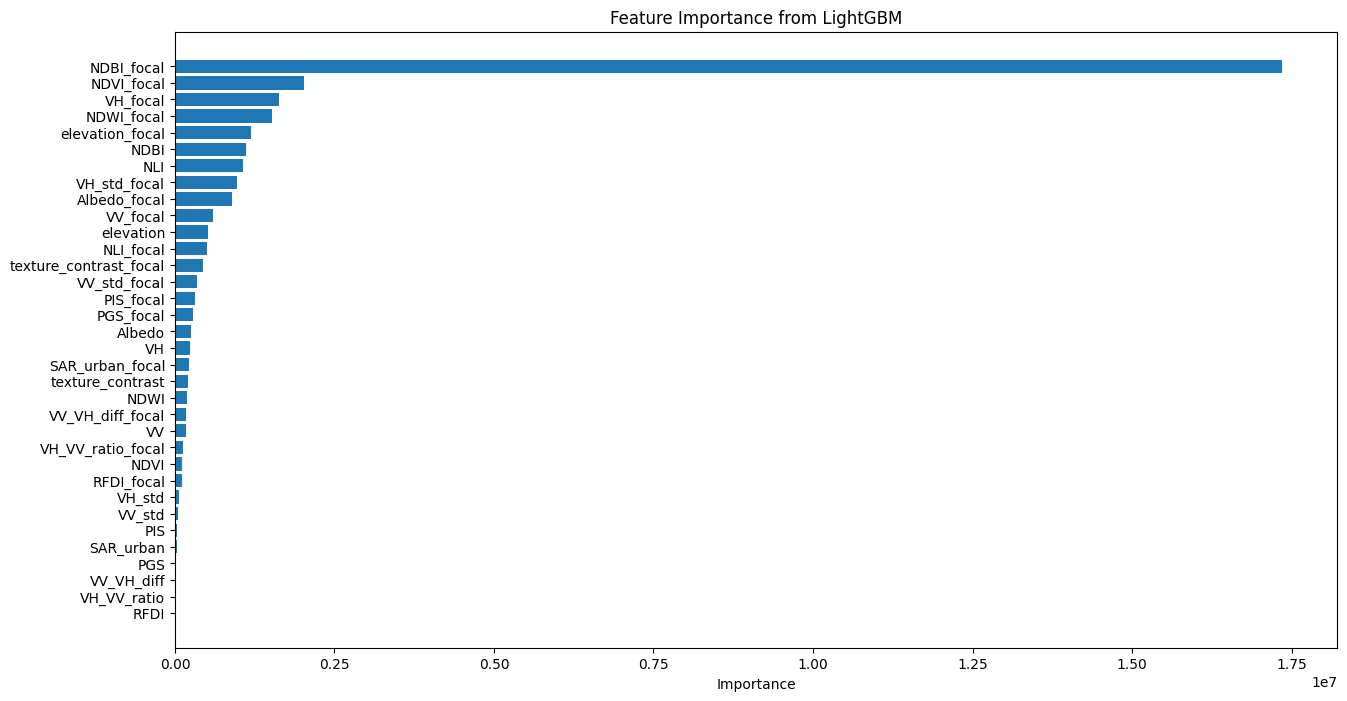

In [59]:
# plote feature importance
importances = baseline_model.booster_.feature_importance(importance_type='gain')
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=True)
plt.figure(figsize=(15, 8))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance from LightGBM')
plt.show()

In [62]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def explain_model_shap(model, X_train, X_test, n_sample=5000, top_n=15):
    """
    Compute and visualise SHAP values for a LightGBM model.
    
    Parameters
    ----------
    model    : trained LGBMRegressor
    X_train  : training features (used to build the SHAP explainer)
    X_test   : test features    (used to compute SHAP values)
    n_sample : number of test rows to explain (full 677k is slow)
    top_n    : how many top features to show in plots
    """

    # ── 1. Sample for speed ───────────────────────────────────────────────────
    # SHAP for tree models is fast but 677k rows still takes minutes.
    # 5000 rows gives stable, representative results.
    rng = np.random.default_rng(42)
    idx = rng.choice(len(X_test), size=min(n_sample, len(X_test)), replace=False)
    X_sample = X_test.iloc[idx].reset_index(drop=True)

    print(f'Computing SHAP values for {len(X_sample):,} sampled test pixels...')

    # ── 2. Build explainer and compute SHAP values ────────────────────────────
    # TreeExplainer is the fast, exact algorithm for tree-based models.
    # It decomposes each prediction into per-feature contributions.
    explainer   = shap.TreeExplainer(model)
    shap_values = explainer(X_sample)   # shape: (n_sample, n_features)

    print(f'SHAP values computed. Shape: {shap_values.values.shape}')
    print(f'Expected value (baseline LST): {explainer.expected_value:.2f} °C')

    # ── 3. Global importance — mean |SHAP| bar plot ───────────────────────────
    # This is the most honest global importance metric:
    # for each feature, average the absolute SHAP value across all samples.
    # A large mean |SHAP| means the feature moves predictions a lot on average.
    fig, ax = plt.subplots(figsize=(10, 8))
    shap.plots.bar(shap_values, max_display=top_n, ax=ax, show=False)
    ax.set_title('Mean |SHAP| — Global Feature Importance', fontsize=13)
    plt.tight_layout()
    plt.show()

    # ── 4. Beeswarm plot — direction + magnitude ──────────────────────────────
    # Each dot is one pixel. Colour = feature value (red=high, blue=low).
    # X position = SHAP value (positive pushes LST up, negative pushes it down).
    # This tells you BOTH how important a feature is AND in which direction.
    fig, ax = plt.subplots(figsize=(10, 8))
    shap.plots.beeswarm(shap_values, max_display=top_n, show=False)
    plt.title('SHAP Beeswarm — Direction and Magnitude per Feature', fontsize=13)
    plt.tight_layout()
    plt.show()

    # ── 5. Dependence plots for top 4 features ────────────────────────────────
    # Shows how SHAP value changes as the feature value changes.
    # The colour shows the interaction with the most correlated other feature.
    # This reveals non-linear relationships the model learned.
    mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
    top_features  = X_sample.columns[np.argsort(mean_abs_shap)[::-1]][:4].tolist()

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for i, feat in enumerate(top_features):
        shap.plots.scatter(
            shap_values[:, feat],
            color=shap_values,
            ax=axes[i],
            show=False
        )
        axes[i].set_title(f'SHAP dependence: {feat}', fontsize=11)
        axes[i].set_xlabel(feat)
        axes[i].set_ylabel('SHAP value (°C contribution)')

    plt.suptitle('SHAP Dependence Plots — Top 4 Features', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

    # ── 6. Waterfall plot — single pixel explanation ──────────────────────────
    # Explains ONE prediction from start to finish:
    # starts at baseline (mean LST), then adds/subtracts each feature's
    # contribution until it reaches the final predicted LST.
    # We show three examples: hottest, coldest, and median predicted pixel.

    preds         = model.predict(X_sample)
    hot_idx       = np.argmax(preds)
    cold_idx      = np.argmin(preds)
    median_idx    = np.argsort(preds)[len(preds) // 2]

    for label, pixel_idx in [('Hottest', hot_idx),
                              ('Coldest', cold_idx),
                              ('Median',  median_idx)]:
        print(f'\n── {label} predicted pixel '
              f'(LST = {preds[pixel_idx]:.1f} °C) ──')
        fig, ax = plt.subplots(figsize=(10, 7))
        shap.plots.waterfall(shap_values[pixel_idx], max_display=12, show=False)
        plt.title(f'SHAP Waterfall — {label} Pixel '
                  f'(predicted LST = {preds[pixel_idx]:.1f} °C)', fontsize=12)
        plt.tight_layout()
        plt.show()

    # ── 7. Return SHAP values for further analysis ────────────────────────────
    shap_df = pd.DataFrame(
        shap_values.values,
        columns=[f'shap_{c}' for c in X_sample.columns]
    )
    shap_df['predicted_LST'] = preds

    return shap_values, shap_df, explainer

Computing SHAP values for 5,000 sampled test pixels...
SHAP values computed. Shape: (5000, 34)
Expected value (baseline LST): 44.67 °C


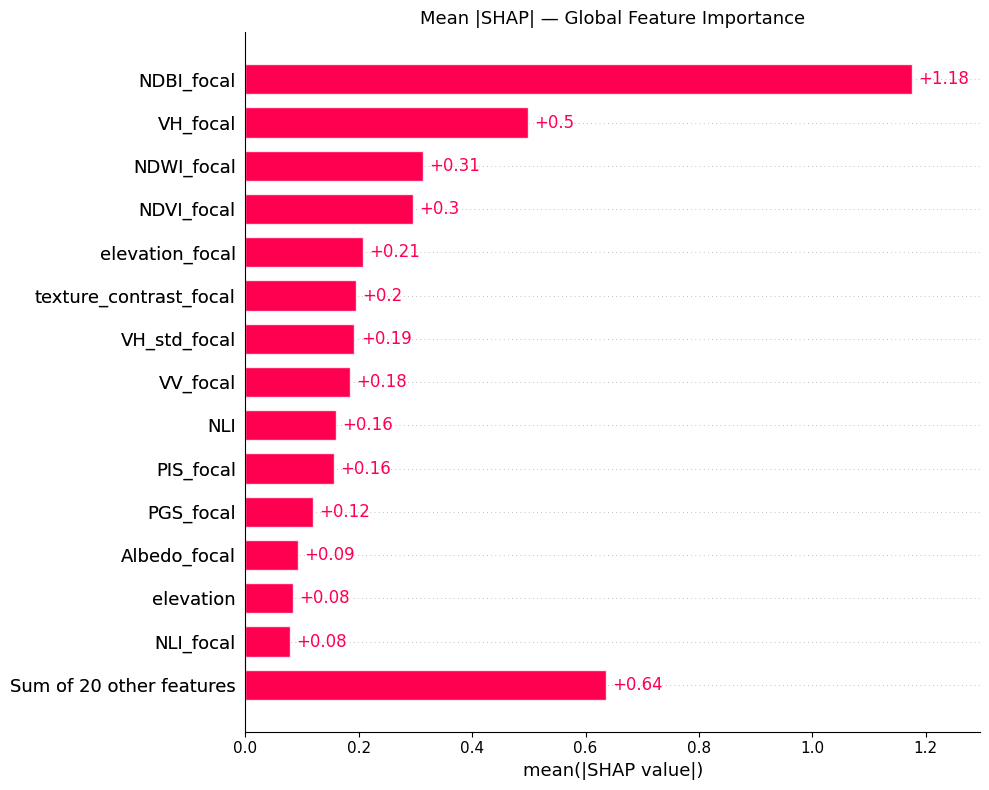

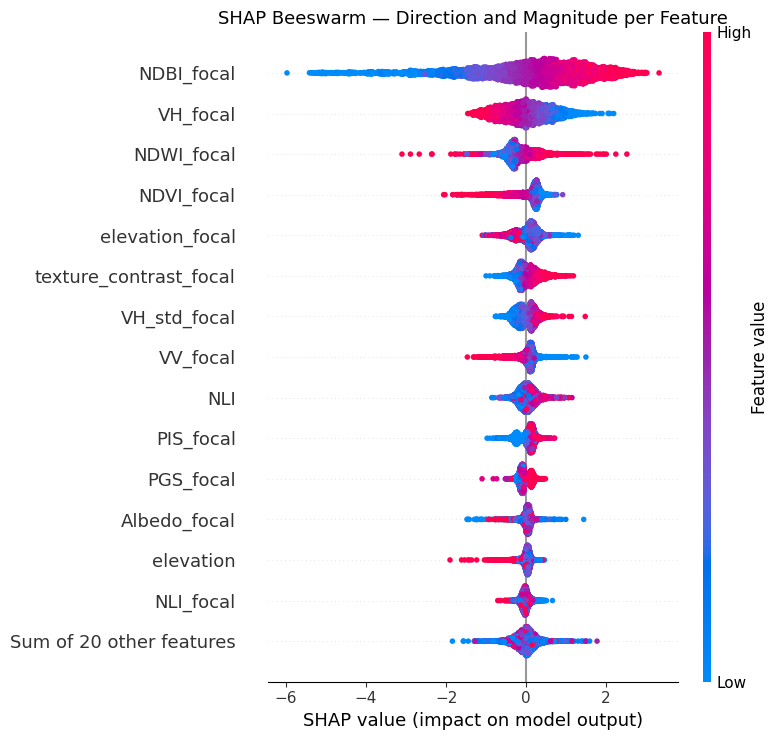

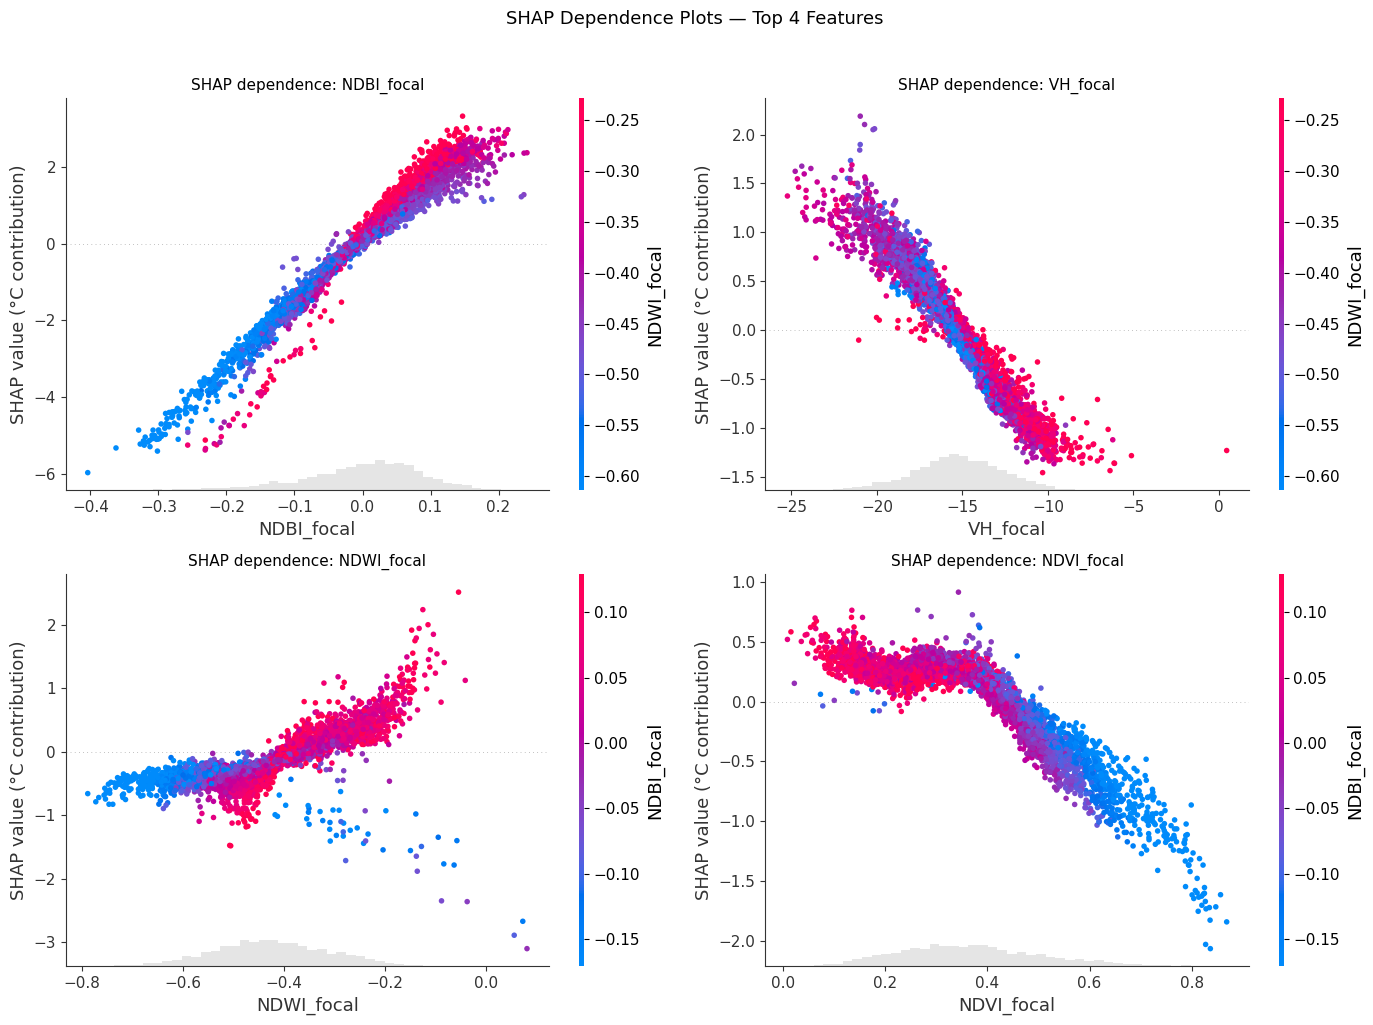


── Hottest predicted pixel (LST = 54.5 °C) ──


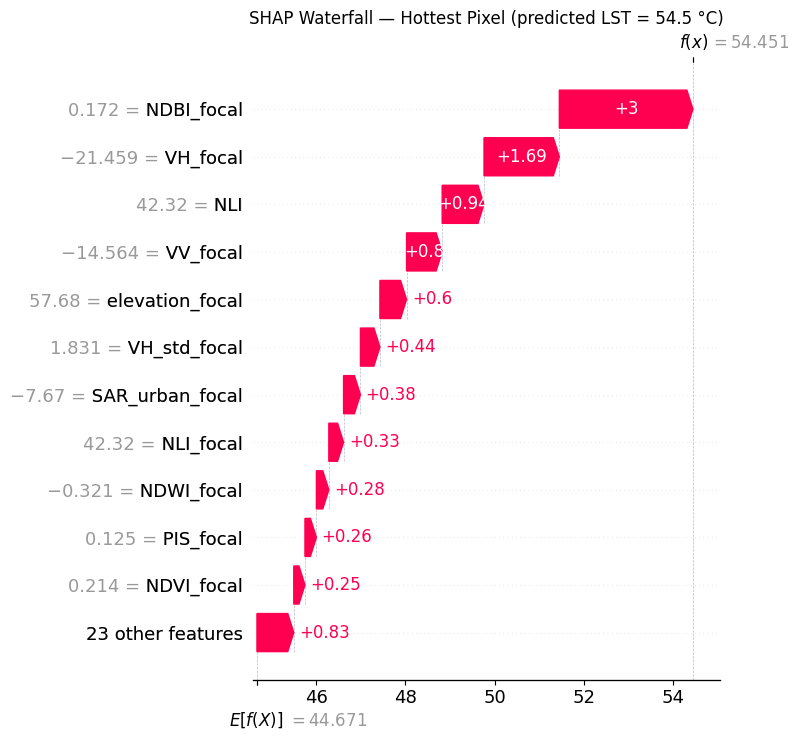


── Coldest predicted pixel (LST = 33.9 °C) ──


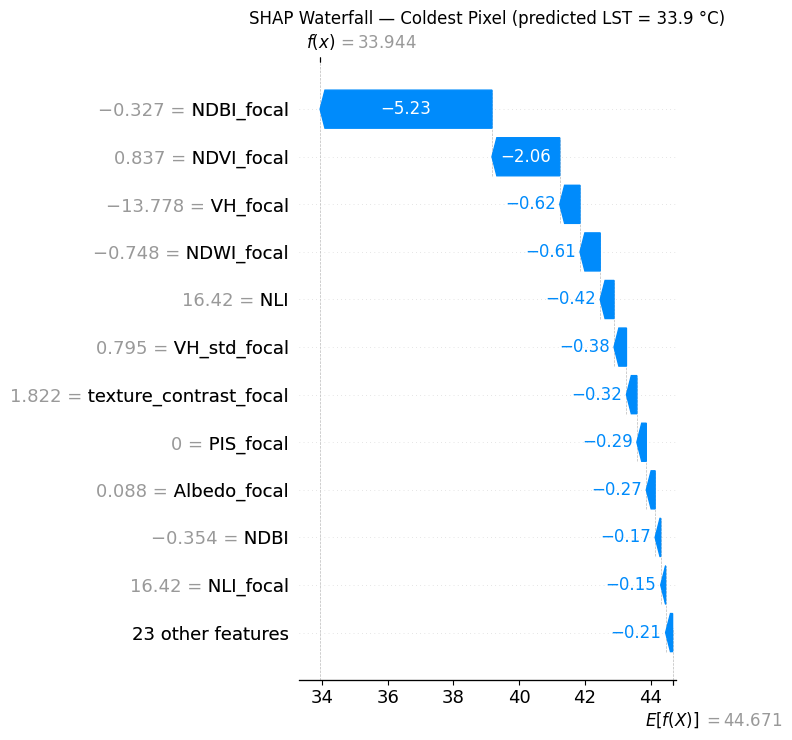


── Median predicted pixel (LST = 44.8 °C) ──


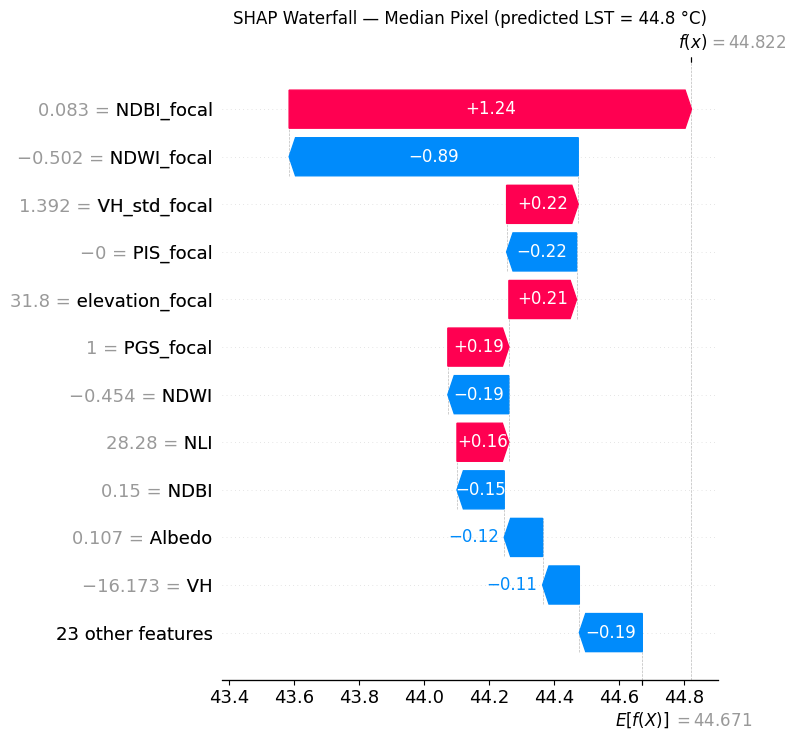

In [63]:

# ── Run it ────────────────────────────────────────────────────────────────────
shap_values, shap_df, explainer = explain_model_shap(
    model    = baseline_model,
    X_train  = X_train,
    X_test   = X_test,
    n_sample = 5000,
    top_n    = 15
)